In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [3]:
data = pd.read_csv(r"C:\Users\91773\Downloads\index.csv")

In [4]:
data.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [5]:
data.shape

(1133, 6)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1133 entries, 0 to 1132
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         1133 non-null   object 
 1   datetime     1133 non-null   object 
 2   cash_type    1133 non-null   object 
 3   card         1044 non-null   object 
 4   money        1133 non-null   float64
 5   coffee_name  1133 non-null   object 
dtypes: float64(1), object(5)
memory usage: 53.2+ KB


In [7]:
data.isnull().sum()

date            0
datetime        0
cash_type       0
card           89
money           0
coffee_name     0
dtype: int64

In [8]:
data.duplicated().sum()

0

In [9]:
data.describe()

,money
count,1133.000000
mean,33.105808
std,5.035366
min,18.120000
25%,28.900000
50%,32.820000
75%,37.720000
max,40.000000


In [10]:
data[['cash_type','coffee_name','card']].describe()

,cash_type,coffee_name,card
count,1133,1133,1044
unique,2,8,446
top,card,Americano with Milk,ANON-0000-0000-0012
freq,1044,268,88


In [11]:
data[data['card'].isnull()]['cash_type'].value_counts()

cash_type
cash    89
Name: count, dtype: int64

<Axes: >

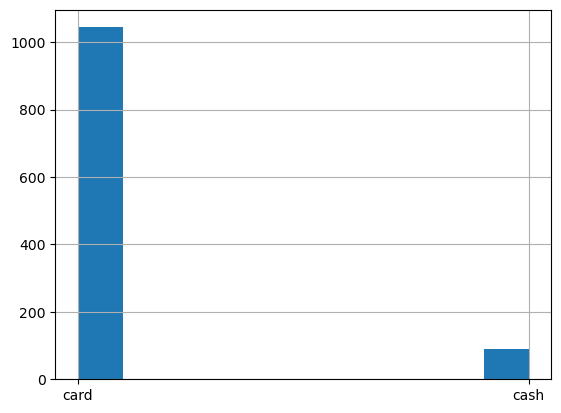

In [12]:
data['cash_type'].hist()

In [13]:
data['cash_type'].value_counts(normalize=True)

cash_type
card    0.921447
cash    0.078553
Name: proportion, dtype: float64

In [14]:
pd.DataFrame(data['coffee_name'].value_counts(normalize = True).sort_values(ascending = False).round(4)*100)

,proportion
coffee_name,
Americano with Milk,23.65
Latte,21.45
Cappuccino,17.30
Americano,14.92
Cortado,8.74
Hot Chocolate,6.53
Espresso,4.32
Cocoa,3.09


In [15]:
data['date']= pd.to_datetime(data['date'])

In [16]:
data['datetime'] = pd.to_datetime(data['datetime'])

In [17]:
data['month']= data['date'].dt.strftime('%Y-%m')
data['day']= data['date'].dt.strftime('%w')
data['hour']= data['datetime'].dt.strftime('%H')

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1133 entries, 0 to 1132
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         1133 non-null   datetime64[ns]
 1   datetime     1133 non-null   datetime64[ns]
 2   cash_type    1133 non-null   object        
 3   card         1044 non-null   object        
 4   money        1133 non-null   float64       
 5   coffee_name  1133 non-null   object        
 6   month        1133 non-null   object        
 7   day          1133 non-null   object        
 8   hour         1133 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(6)
memory usage: 79.8+ KB


In [19]:
data.head(20)

,date,datetime,cash_type,card,money,coffee_name,month,day,hour
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,2024-03,5,10
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,2024-03,5,12
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate,2024-03,5,12
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano,2024-03,5,13
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte,2024-03,5,13
5,2024-03-01,2024-03-01 15:39:47.726,card,ANON-0000-0000-0005,33.8,Americano with Milk,2024-03,5,15
6,2024-03-01,2024-03-01 16:19:02.756,card,ANON-0000-0000-0006,38.7,Hot Chocolate,2024-03,5,16
7,2024-03-01,2024-03-01 18:39:03.580,card,ANON-0000-0000-0007,33.8,Americano with Milk,2024-03,5,18
8,2024-03-01,2024-03-01 19:22:01.762,card,ANON-0000-0000-0008,38.7,Cocoa,2024-03,5,19
9,2024-03-01,2024-03-01 19:23:15.887,card,ANON-0000-0000-0008,33.8,Americano with Milk,2024-03,5,19


In [20]:
[data['date'].min()]

[Timestamp('2024-03-01 00:00:00')]

In [21]:
[data['date'].max()]

[Timestamp('2024-07-31 00:00:00')]

In [22]:
revenuedata = data.groupby(['coffee_name']).sum(['money']).reset_index().sort_values(by='money',ascending = False)

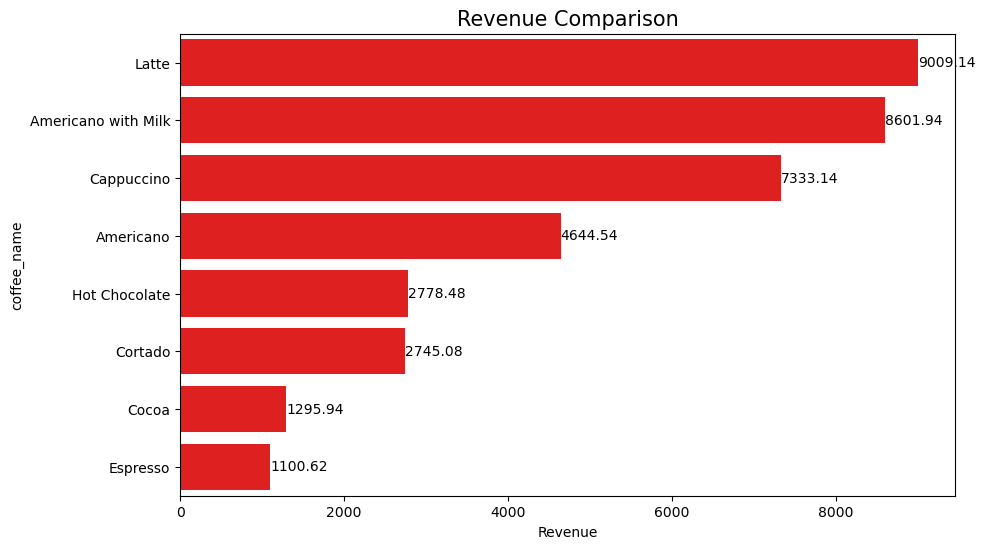

In [23]:
plt.figure(figsize=(10,6))
revenue_plt = sns.barplot(data= revenuedata, 
                          x = 'money', y = 'coffee_name',
                          color = 'red')
plt.xlabel('Revenue')
plt.title('Revenue Comparison', color ='k', fontsize = 15)
revenue_plt.bar_label(revenue_plt.containers[0], fontsize = 10)
plt.show()

In [24]:
monthly_sales = (
    data.groupby(['coffee_name', 'month'])
    .count()['date']
    .reset_index()
    .rename(columns={'date': 'count'})
    .pivot(index='month', columns='coffee_name', values='count')
    .reset_index()
)

monthly_sales


coffee_name,month,Americano,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
0,2024-03,36,34,20,6,30,10,22,48
1,2024-04,35,42,43,6,19,7,13,31
2,2024-05,48,58,55,9,17,8,14,58
3,2024-06,14,69,46,5,19,10,14,50
4,2024-07,36,65,32,9,14,14,11,56


In [25]:
monthly_sales.describe()

coffee_name,Americano,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,33.800000,53.600000,39.200000,7.000000,19.800000,9.800000,14.800000,48.600000
std,12.296341,15.043271,13.516656,1.870829,6.058052,2.683282,4.207137,10.667708
min,14.000000,34.000000,20.000000,5.000000,14.000000,7.000000,11.000000,31.000000
25%,35.000000,42.000000,32.000000,6.000000,17.000000,8.000000,13.000000,48.000000
50%,36.000000,58.000000,43.000000,6.000000,19.000000,10.000000,14.000000,50.000000
75%,36.000000,65.000000,46.000000,9.000000,19.000000,10.000000,14.000000,56.000000
max,48.000000,69.000000,55.000000,9.000000,30.000000,14.000000,22.000000,58.000000


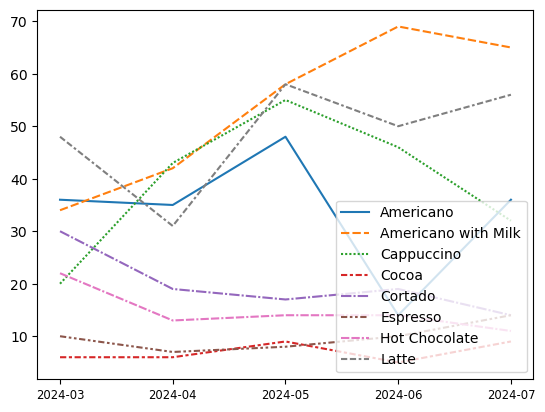

In [26]:
sns.lineplot(data= monthly_sales)
plt.legend(loc = 4)
plt.xticks(range(len(monthly_sales['month'])),monthly_sales['month'], size = 'small')
plt.show()

In [27]:
weekday_sales = data.groupby(['day']).count()['date'].reset_index().rename(columns ={'date':'count'})

In [28]:
weekday_sales

,day,count
0,0,151
1,1,151
2,2,185
3,3,165
4,4,164
5,5,163
6,6,154


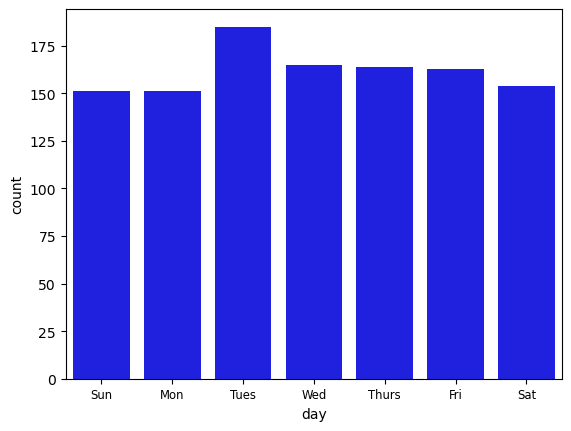

In [29]:
sns.barplot(data=weekday_sales, x= 'day', y = 'count',color = 'blue')
plt.xticks(range(len(weekday_sales['day'])),['Sun','Mon','Tues','Wed','Thurs','Fri','Sat'],size = 'small')
plt.show()

In [30]:
daily_sales = data.groupby(['coffee_name', 'date']).count()['datetime'].reset_index().reset_index().rename(columns = {'datetime':'count'}).pivot(index ='date',columns = 'coffee_name', values = 'count').reset_index().fillna(0)

In [31]:
daily_sales.head()

coffee_name,date,Americano,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
0,2024-03-01,1.0,4.0,0.0,1.0,0.0,0.0,3.0,2.0
1,2024-03-02,3.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2024-03-03,1.0,2.0,0.0,1.0,2.0,0.0,2.0,2.0
3,2024-03-04,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0
4,2024-03-05,0.0,0.0,0.0,1.0,1.0,0.0,4.0,3.0


In [32]:
daily_sales.iloc[:, 1:].describe().loc[['min', 'max']]


coffee_name,Americano,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,5.0,12.0,9.0,2.0,4.0,4.0,4.0,7.0


In [33]:
hourly_sales = data.groupby(['hour']).count()['date'].reset_index().rename(columns = {'date':'count'})
hourly_sales

,hour,count
0,07,13
1,08,44
2,09,50
3,10,133
4,11,103
5,12,87
6,13,78
7,14,76
8,15,65
9,16,77


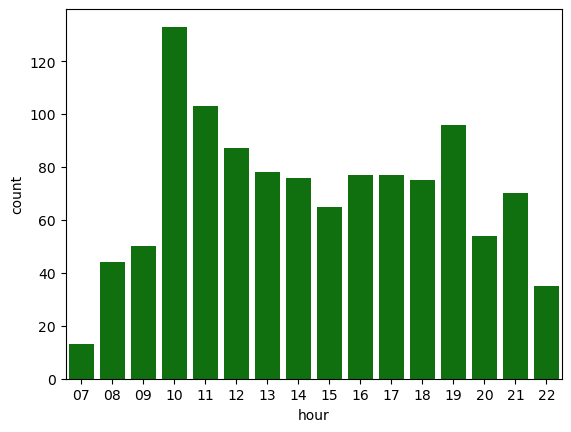

In [34]:
sns.barplot(data = hourly_sales, x = 'hour', y = 'count', color = 'green')
plt.show()

In [35]:
hourly_sales_by_coffee = data.groupby(['hour', 'coffee_name']).count()['date'].reset_index().rename(columns = {'date':'count'}).pivot(index = 'hour',columns = 'coffee_name', values = 'count').fillna(0).reset_index()
hourly_sales_by_coffee

coffee_name,hour,Americano,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
0,07,5.0,4.0,1.0,0.0,1.0,0.0,0.0,2.0
1,08,10.0,7.0,8.0,1.0,6.0,0.0,0.0,12.0
2,09,8.0,16.0,6.0,1.0,5.0,3.0,0.0,11.0
3,10,20.0,31.0,10.0,4.0,8.0,2.0,7.0,51.0
4,11,21.0,25.0,16.0,1.0,13.0,6.0,8.0,13.0
5,12,14.0,26.0,15.0,3.0,7.0,6.0,3.0,13.0
6,13,18.0,18.0,10.0,2.0,12.0,3.0,4.0,11.0
7,14,15.0,18.0,13.0,4.0,6.0,5.0,2.0,13.0
8,15,14.0,15.0,8.0,0.0,3.0,4.0,6.0,15.0
9,16,10.0,18.0,12.0,3.0,12.0,5.0,4.0,13.0


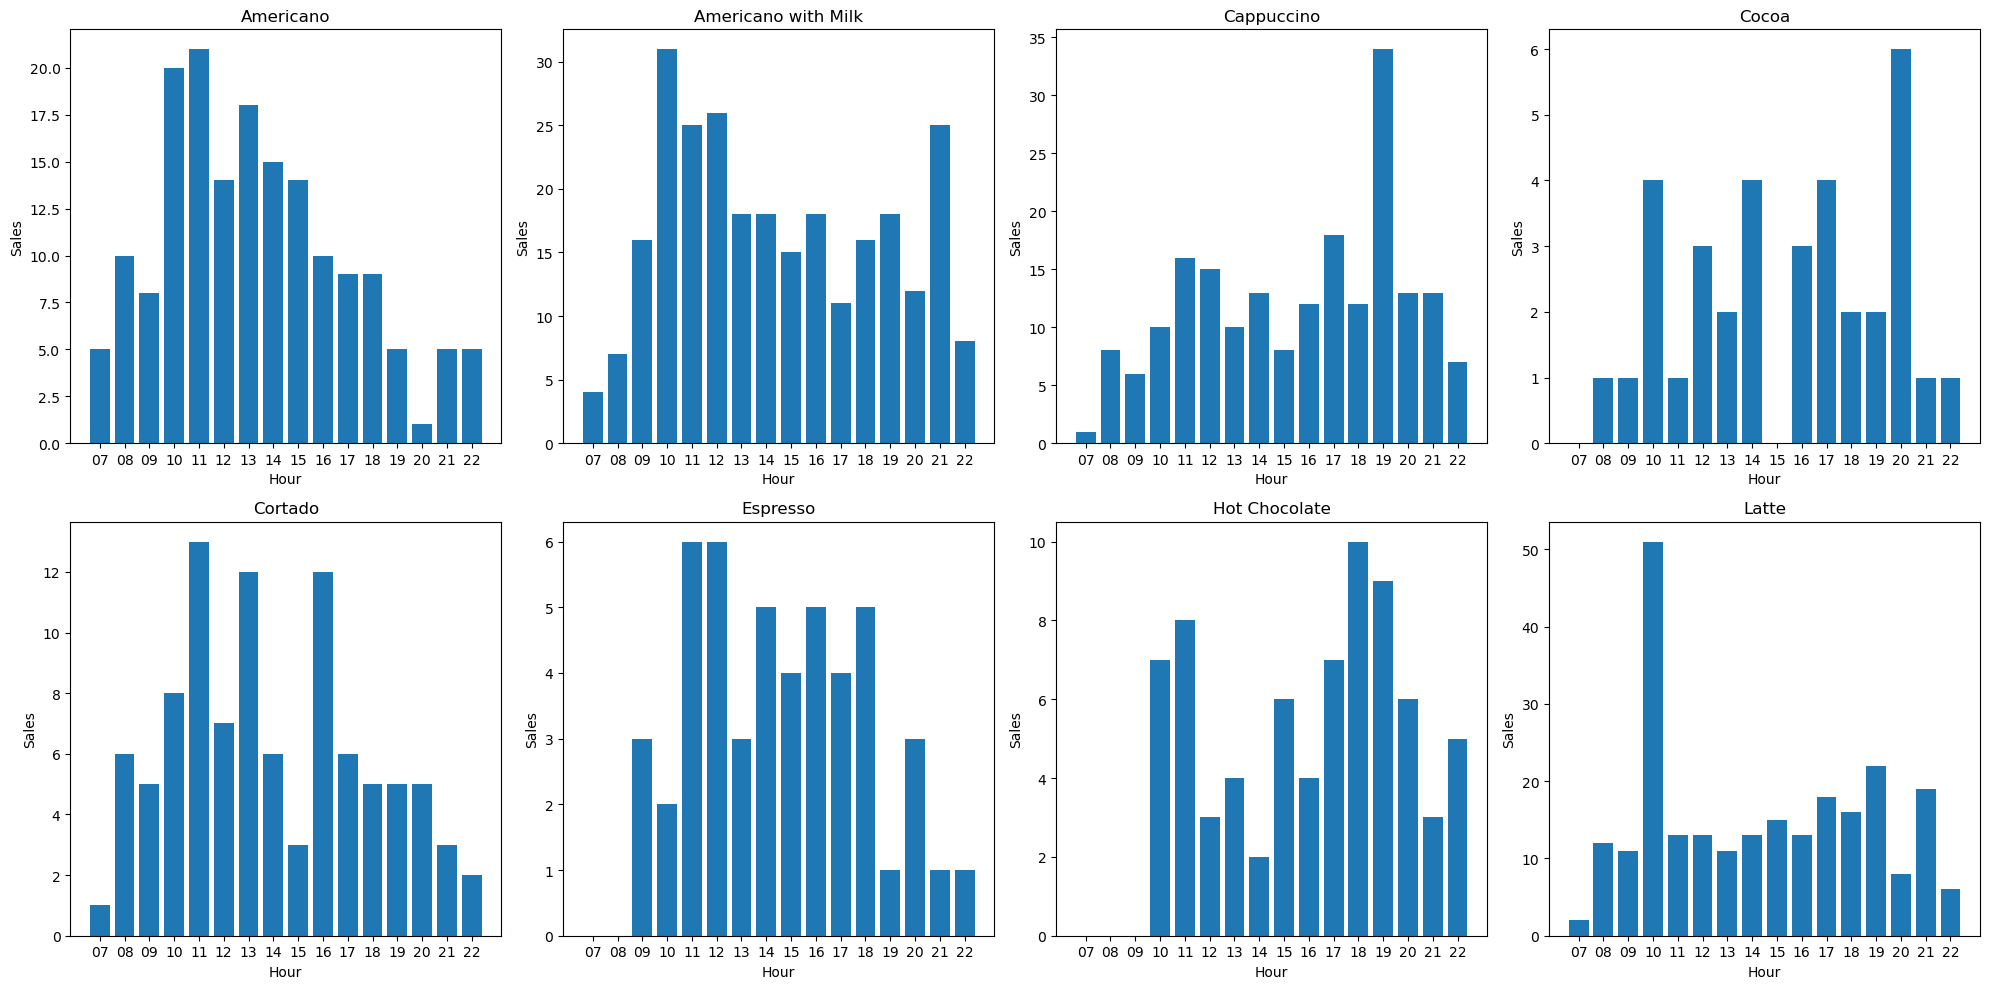

In [36]:
fig, revenue_plt = plt.subplots(2, 4, figsize=(20, 10))
revenue_plt = revenue_plt.flatten()  # Flatten the 2D array of axes

# Loop through each coffee column (excluding 'hour')
for i, column in enumerate(hourly_sales_by_coffee.columns[1:]):  
    revenue_plt[i].bar(hourly_sales_by_coffee['hour'], hourly_sales_by_coffee[column])
    revenue_plt[i].set_title(f'{column}')
    revenue_plt[i].set_xlabel('Hour')
    revenue_plt[i].set_ylabel('Sales')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()